# Price Elasticity Model
- Justin Wall, Data Scientist, Kettlerock Brewing Co.

## Section 1: Data Import

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/kettlerock_sales.csv', parse_dates=['week'])

In [12]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(4236, 16)
week                   datetime64[us]
year                            int64
week_of_year                    int64
season                            str
region                            str
sku_id                            str
sku_name                          str
category                          str
pack_size                         str
is_seasonal_release              bool
price                         float64
is_promo                         bool
promo_event                       str
hawkstone_price               float64
units_sold                      int64
revenue                       float64
dtype: object
week                      0
year                      0
week_of_year              0
season                    0
region                    0
sku_id                    0
sku_name                  0
category                  0
pack_size                 0
is_seasonal_release       0
price                     0
is_promo                  0
promo_event            4026
haw

In [13]:
print(df[['price','units_sold','revenue']].describe().round(2))
print(df['region'].value_counts())
print(df['category'].value_counts())
print(df['week'].min(), df['week'].max())

         price  units_sold  revenue
count  4236.00     4236.00  4236.00
mean     15.44      138.24  2123.86
std       4.48       61.07  1183.02
min       9.22       14.00   356.86
25%      11.76       91.00  1230.96
50%      13.50      130.00  1853.35
75%      19.99      178.00  2686.09
max      27.21      352.00  7295.53
region
Twin Cities      1412
Chicago          1412
Upper Midwest    1412
Name: count, dtype: int64
category
IPA      1362
Stout     852
Lager     816
Sour      678
Mixed     312
Wheat     216
Name: count, dtype: int64
2022-01-03 00:00:00 2023-12-25 00:00:00


***
### **Notes**:
- 3 Regions
- 6 categories
- price, units sold, revenue
***

## Data Alignment - Business

### Part 1 -> Portfolio Summary

In [14]:
summary = (
    df.groupby(['sku_id', 'sku_name', 'category', 'pack_size', 'is_seasonal_release'])
    .agg(
        weeks_in_market  = ('week',       'nunique'),
        avg_price        = ('price',       'mean'),
        price_min        = ('price',       'min'),
        price_max        = ('price',       'max'),
        avg_weekly_units = ('units_sold',  'mean'),
        avg_weekly_rev   = ('revenue',     'mean'),
        promo_weeks      = ('is_promo',    'sum'),
    )
    .round(2)
    .reset_index()
)
summary

,sku_id,sku_name,category,pack_size,is_seasonal_release,weeks_in_market,avg_price,price_min,price_max,avg_weekly_units,avg_weekly_rev,promo_weeks
0,SKU001,Irongate IPA,IPA,6-pack,False,104,12.09,10.41,13.33,126.04,1522.81,18
1,SKU002,Irongate IPA,IPA,12-pack,False,104,22.40,19.22,24.20,164.80,3678.80,18
2,SKU003,Copperhead Hazy IPA,IPA,6-pack,False,104,13.68,11.97,14.80,124.12,1697.25,18
3,SKU004,Trailblazer Session IPA,IPA,6-pack,True,38,11.21,9.37,12.33,179.05,2003.85,18
4,SKU005,Double Irongate DIPA,IPA,4-pack,False,104,16.22,13.64,17.84,56.18,911.17,18
5,SKU006,Summit Stout,Stout,6-pack,False,104,11.56,9.78,12.57,124.01,1428.25,12
6,SKU007,Summit Stout,Stout,12-pack,False,104,21.43,18.47,23.14,163.79,3504.44,12
7,SKU008,Midnight Porter,Stout,6-pack,True,38,11.16,9.57,12.20,174.25,1954.46,6
8,SKU009,Barrel-Aged Summit,Stout,4-pack,True,38,20.27,18.39,21.63,80.24,1624.24,6
9,SKU010,Kettlerock Lager,Lager,6-pack,False,104,10.19,9.99,10.39,123.35,1260.27,0


Part 2 -> Price over time with promo flags and Hawkstone overlay

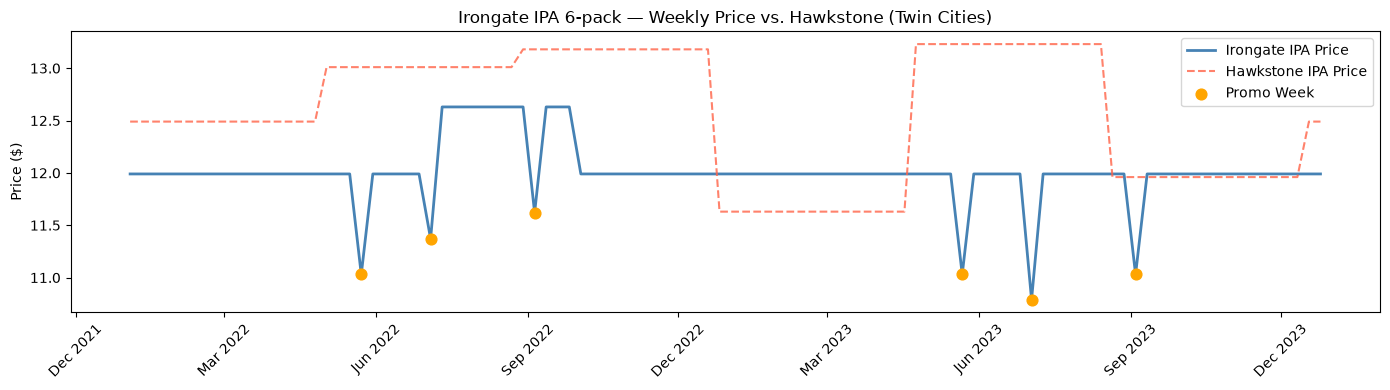

In [15]:
sku    = 'SKU001'
region = 'Twin Cities'

sku_df  = df[(df.sku_id == sku) & (df.region == region)].copy()
promos  = sku_df[sku_df.is_promo]
hawk_df = sku_df[sku_df.hawkstone_price.notna()]

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(sku_df.week, sku_df.price, label='Irongate IPA Price', color='steelblue', linewidth=2)
ax.plot(hawk_df.week, hawk_df.hawkstone_price, label='Hawkstone IPA Price',
        color='tomato', linewidth=1.5, linestyle='--', alpha=0.8)
ax.scatter(promos.week, promos.price, color='orange', zorder=5,
           label='Promo Week', s=60)

ax.set_title('Irongate IPA 6-pack — Weekly Price vs. Hawkstone (Twin Cities)')
ax.set_ylabel('Price ($)')
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Part 3 -> Volume over time by region

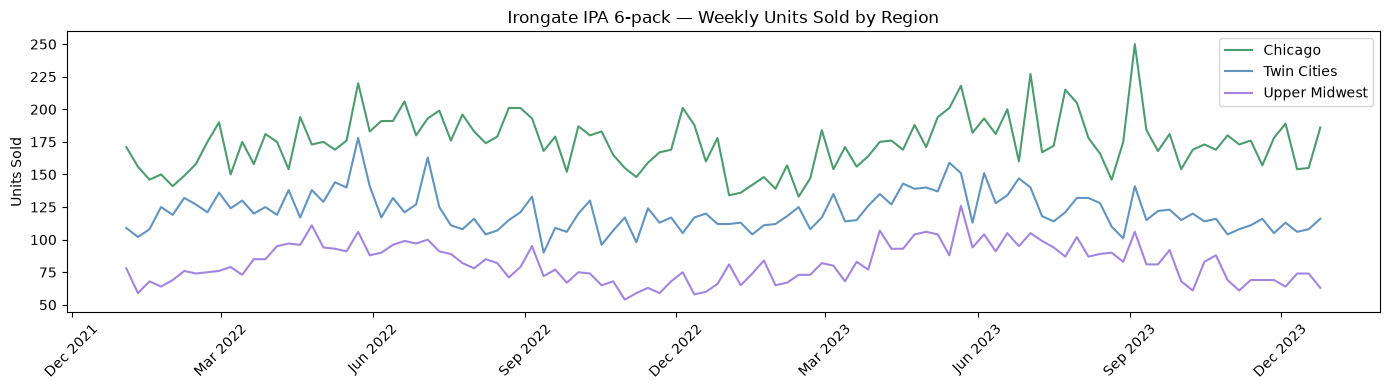

In [16]:
fig, ax = plt.subplots(figsize=(14, 4))

colors = {'Twin Cities': 'steelblue', 'Chicago': 'seagreen', 'Upper Midwest': 'mediumpurple'}

for region, grp in df[df.sku_id == 'SKU001'].groupby('region'):
    ax.plot(grp.week, grp.units_sold, label=region,
            color=colors[region], linewidth=1.5, alpha=0.85)

ax.set_title('Irongate IPA 6-pack — Weekly Units Sold by Region')
ax.set_ylabel('Units Sold')
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Part 4 -> Answer to Mara's specific question

In [17]:
sku_tc = df[(df.sku_id == 'SKU001') & (df.region == 'Twin Cities')].copy()
sku_tc[['week','price','units_sold','revenue','is_promo']].head(30)

,week,price,units_sold,revenue,is_promo
0,2022-01-03,11.99,109,1306.91,False
1,2022-01-10,11.99,102,1222.98,False
2,2022-01-17,11.99,108,1294.92,False
3,2022-01-24,11.99,125,1498.75,False
4,2022-01-31,11.99,119,1426.81,False
5,2022-02-07,11.99,132,1582.68,False
6,2022-02-14,11.99,127,1522.73,False
7,2022-02-21,11.99,121,1450.79,False
8,2022-02-28,11.99,136,1630.64,False
9,2022-03-07,11.99,124,1486.76,False


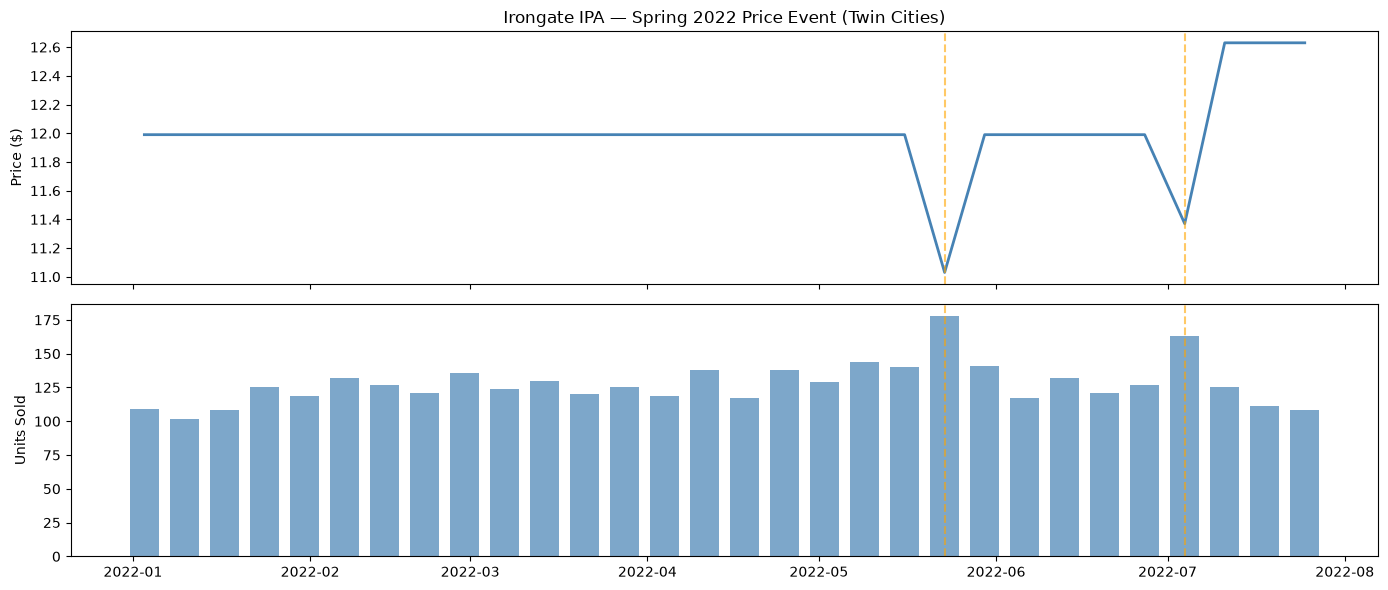

In [18]:
window = sku_tc[(sku_tc.week >= '2022-01-01') & (sku_tc.week <= '2022-07-31')]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(window.week, window.price, color='steelblue', linewidth=2)
ax1.set_ylabel('Price ($)')
ax1.set_title("Irongate IPA — Spring 2022 Price Event (Twin Cities)")

ax2.bar(window.week, window.units_sold, color='steelblue', alpha=0.7, width=5)
ax2.set_ylabel('Units Sold')

# flag promos
for _, row in window[window.is_promo].iterrows():
    ax1.axvline(row.week, color='orange', linestyle='--', alpha=0.6)
    ax2.axvline(row.week, color='orange', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [19]:
# Quick revenue math around the price change
before = window[window.week < '2022-04-01']
after  = window[window.week >= '2022-04-01']

print(f"Avg weekly units before: {before.units_sold.mean():.0f}")
print(f"Avg weekly units after:  {after.units_sold.mean():.0f}")
print(f"Avg weekly revenue before: ${before.revenue.mean():.0f}")
print(f"Avg weekly revenue after:  ${after.revenue.mean():.0f}")

# Did lager pick up? Cross-SKU substitution check
lager_tc = df[(df.sku_id == 'SKU010') & (df.region == 'Twin Cities')]
lager_window = lager_tc[(lager_tc.week >= '2022-01-01') & (lager_tc.week <= '2022-07-31')]
print(f"\nLager avg units before: {lager_window[lager_window.week < '2022-04-01'].units_sold.mean():.0f}")
print(f"Lager avg units after:  {lager_window[lager_window.week >= '2022-04-01'].units_sold.mean():.0f}")

Avg weekly units before: 121
Avg weekly units after:  132
Avg weekly revenue before: $1455
Avg weekly revenue after:  $1582

Lager avg units before: 116
Lager avg units after:  128


***
### **Notes**:

***